In [1]:
import json
import pandas as pd
import numpy as np
from FCPython import createPitch
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from datetime import datetime

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

## Load one season of LaLiga data

In [2]:
with open('C:/Users/matth/Google Drive/Data Science/Football Analytics/SoccermaticsForPython-master/Statsbomb/data/competitions.json') as f:
    competitions = json.load(f)
competitions

[{'competition_id': 16,
  'season_id': 4,
  'country_name': 'Europe',
  'competition_name': 'Champions League',
  'competition_gender': 'male',
  'season_name': '2018/2019',
  'match_updated': '2020-07-29T05:00',
  'match_available': '2020-07-29T05:00'},
 {'competition_id': 16,
  'season_id': 1,
  'country_name': 'Europe',
  'competition_name': 'Champions League',
  'competition_gender': 'male',
  'season_name': '2017/2018',
  'match_updated': '2020-07-29T05:00',
  'match_available': '2020-07-29T05:00'},
 {'competition_id': 16,
  'season_id': 2,
  'country_name': 'Europe',
  'competition_name': 'Champions League',
  'competition_gender': 'male',
  'season_name': '2016/2017',
  'match_updated': '2020-08-26T12:33:15.869622',
  'match_available': '2020-07-29T05:00'},
 {'competition_id': 16,
  'season_id': 27,
  'country_name': 'Europe',
  'competition_name': 'Champions League',
  'competition_gender': 'male',
  'season_name': '2015/2016',
  'match_updated': '2020-08-26T12:33:15.869622',
 

In [7]:
competition_id=11
season_ids = [37]
#Load the list of matches for this competition

all_games = pd.DataFrame(None)

for season_id in season_ids:
    with open(f'C:/Users/matth/Google Drive/Data Science/Football Analytics/SoccermaticsForPython-master/Statsbomb/data/matches/{str(competition_id)}/{str(season_id)}.json', encoding='utf-8') as f:
        matches = json.load(f)
        season_json = pd.json_normalize(matches, sep = "_")
        all_games = pd.concat([all_games,season_json],axis=0)
    
print(all_games.shape)
all_games.head()

(7, 38)


,match_id,match_date,kick_off,home_score,away_score,match_status,last_updated,match_week,competition_competition_id,competition_country_name,competition_competition_name,season_season_id,season_season_name,home_team_home_team_id,home_team_home_team_name,home_team_home_team_gender,home_team_home_team_group,home_team_country_id,home_team_country_name,away_team_away_team_id,away_team_away_team_name,away_team_away_team_gender,away_team_away_team_group,away_team_country_id,away_team_country_name,metadata_data_version,metadata_shot_fidelity_version,metadata_xy_fidelity_version,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,68314,2004-12-04,20:00:00.000,4,0,available,2020-07-29T05:00,14,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,223,Málaga,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,993,José Omar Losantos,NaN,NaN
1,68313,2004-10-24,21:00:00.000,3,0,available,2020-07-29T05:00,8,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,422,Osasuna,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,994,Vicente José Lizondo Cortés,NaN,NaN
2,68316,2005-05-01,19:00:00.000,2,0,available,2020-07-29T05:00,34,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,608,Albacete,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,407,Carlos Velasco Carballo,214.0,Spain
3,68315,2004-12-21,20:00:00.000,2,1,available,2020-07-29T05:00,17,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,221,Levante,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,222,David Fernández,112.0,Italy
4,69153,2004-12-11,20:00:00.000,1,2,available,2020-07-29T05:00,15,11,Spain,La Liga,37,2004/2005,608,Albacete,male,None,214,Spain,217,Barcelona,male,None,214,Spain,1.1.0,2,2,1,Regular Season,4448,Estadio Carlos Belmonte,214,Spain,1007,Alfonso Perez Burrull,NaN,NaN


In [8]:
#chosen = all_games[((all_games['home_team_home_team_name'] == 'Croatia') & (all_games['away_team_away_team_name'] == 'Argentina'))
#          |((all_games['home_team_home_team_name'] == 'Argentina') & (all_games['away_team_away_team_name'] == 'Croatia'))]

chosen = all_games

chosen_ids = chosen['match_id']

chosen.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,last_updated,match_week,competition_competition_id,competition_country_name,competition_competition_name,season_season_id,season_season_name,home_team_home_team_id,home_team_home_team_name,home_team_home_team_gender,home_team_home_team_group,home_team_country_id,home_team_country_name,away_team_away_team_id,away_team_away_team_name,away_team_away_team_gender,away_team_away_team_group,away_team_country_id,away_team_country_name,metadata_data_version,metadata_shot_fidelity_version,metadata_xy_fidelity_version,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,68314,2004-12-04,20:00:00.000,4,0,available,2020-07-29T05:00,14,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,223,Málaga,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,993,José Omar Losantos,NaN,NaN
1,68313,2004-10-24,21:00:00.000,3,0,available,2020-07-29T05:00,8,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,422,Osasuna,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,994,Vicente José Lizondo Cortés,NaN,NaN
2,68316,2005-05-01,19:00:00.000,2,0,available,2020-07-29T05:00,34,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,608,Albacete,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,407,Carlos Velasco Carballo,214.0,Spain
3,68315,2004-12-21,20:00:00.000,2,1,available,2020-07-29T05:00,17,11,Spain,La Liga,37,2004/2005,217,Barcelona,male,None,214,Spain,221,Levante,male,None,214,Spain,1.1.0,2,2,1,Regular Season,342,Camp Nou,214,Spain,222,David Fernández,112.0,Italy
4,69153,2004-12-11,20:00:00.000,1,2,available,2020-07-29T05:00,15,11,Spain,La Liga,37,2004/2005,608,Albacete,male,None,214,Spain,217,Barcelona,male,None,214,Spain,1.1.0,2,2,1,Regular Season,4448,Estadio Carlos Belmonte,214,Spain,1007,Alfonso Perez Burrull,NaN,NaN


In [9]:
chosen_ids = all_games['match_id']

first_pass=True
for id in chosen_ids:
    with open("C:/Users/matth/Google Drive/Data Science/Football Analytics/SoccermaticsForPython-master/Statsbomb/data/events/"+str(id)+".json", encoding='utf-8') as f:
        events = json.load(f)
        all_matches = pd.json_normalize(events, sep = "_")
all_matches.head()

,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_id,team_name,tactics_formation,tactics_lineup,related_events,location,player_id,player_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_type_id,pass_type_name,pass_body_part_id,pass_body_part_name,carry_end_location,under_pressure,pass_outcome_id,pass_outcome_name,ball_receipt_outcome_id,ball_receipt_outcome_name,pass_switch,duel_outcome_id,duel_outcome_name,duel_type_id,duel_type_name,off_camera,pass_cross,goalkeeper_outcome_id,goalkeeper_outcome_name,goalkeeper_type_id,goalkeeper_type_name,clearance_left_foot,clearance_body_part_id,clearance_body_part_name,ball_recovery_recovery_failure,foul_won_defensive,clearance_head,dribble_outcome_id,dribble_outcome_name,counterpress,out,pass_aerial_won,clearance_right_foot,clearance_aerial_won,pass_assisted_shot_id,pass_shot_assist,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_outcome_id,shot_outcome_name,shot_type_id,shot_type_name,shot_body_part_id,shot_body_part_name,shot_technique_id,shot_technique_name,shot_first_time,shot_freeze_frame,goalkeeper_end_location,goalkeeper_position_id,goalkeeper_position_name,pass_goal_assist,shot_deflected,block_deflection,goalkeeper_technique_id,goalkeeper_technique_name,goalkeeper_body_part_id,goalkeeper_body_part_name,pass_outswinging,pass_technique_id,pass_technique_name,interception_outcome_id,interception_outcome_name,shot_aerial_won,foul_committed_advantage,foul_won_advantage,pass_inswinging,shot_one_on_one,pass_straight,dribble_overrun,foul_committed_type_id,foul_committed_type_name,foul_committed_card_id,foul_committed_card_name,pass_through_ball,substitution_outcome_id,substitution_outcome_name,substitution_replacement_id,substitution_replacement_name,pass_no_touch,pass_cut_back,ball_recovery_offensive
0,3b66ba10-464a-4fc4-b1f1-081384c134f0,1,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,214,Espanyol,1,Regular Play,214,Espanyol,433.0,"[{'player': {'id': 26103, 'name': 'Idriss Carl...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,51278bda-3e4e-4887-9c39-04b7522b39d5,2,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,214,Espanyol,1,Regular Play,217,Barcelona,433.0,"[{'player': {'id': 20176, 'name': 'Víctor Vald...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,99020799-c2fe-407d-b830-a93ff5eb6b06,3,1,00:00:00.000,0,0,1,0.000000,18,Half Start,214,Espanyol,1,Regular Play,217,Barcelona,NaN,NaN,[6b838dec-5b3f-4df8-9f0b-3f275ee03b0a],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6b838dec-5b3f-4df8-9f0b-3f275ee03b0a,4,1,00:00:00.000,0,0,1,0.000000,18,Half Start,214,Espanyol,1,Regular Play,214,Espanyol,NaN,NaN,[99020799-c2fe-407d-b830-a93ff5eb6b06],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [12]:
all_matches.shape

(2770, 114)

In [13]:
all_matches.type_name.unique()

array(['Starting XI', 'Half Start', 'Pass', 'Ball Receipt*', 'Carry',
       'Pressure', 'Dispossessed', 'Duel', 'Ball Recovery',
       'Foul Committed', 'Foul Won', 'Goal Keeper', 'Clearance',
       'Dribbled Past', 'Dribble', 'Shot', 'Block', 'Miscontrol',
       'Offside', 'Interception', 'Shield', 'Half End', 'Injury Stoppage',
       'Substitution', 'Tactical Shift'], dtype=object)

Run some analysis to check whether the 'Under Pressure' column is correctly produced

In [15]:
passes = all_matches[all_matches.type_name == 'Pass']
print(passes.shape)

(786, 114)


In [16]:
passes = passes.explode('related_events')

Join all related events to passes

In [19]:
passes_pressure = pd.merge(passes,all_matches[['id','type_name']],left_on = 'related_events',right_on='id')

In [20]:
passes_pressure.head()

,id_x,index,period,timestamp,minute,second,possession,duration,type_id,type_name_x,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_id,team_name,tactics_formation,tactics_lineup,related_events,location,player_id,player_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_type_id,pass_type_name,pass_body_part_id,pass_body_part_name,carry_end_location,under_pressure,pass_outcome_id,pass_outcome_name,ball_receipt_outcome_id,ball_receipt_outcome_name,pass_switch,duel_outcome_id,duel_outcome_name,duel_type_id,duel_type_name,off_camera,pass_cross,goalkeeper_outcome_id,goalkeeper_outcome_name,goalkeeper_type_id,goalkeeper_type_name,clearance_left_foot,clearance_body_part_id,clearance_body_part_name,ball_recovery_recovery_failure,foul_won_defensive,clearance_head,dribble_outcome_id,dribble_outcome_name,counterpress,out,pass_aerial_won,clearance_right_foot,clearance_aerial_won,pass_assisted_shot_id,pass_shot_assist,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_outcome_id,shot_outcome_name,shot_type_id,shot_type_name,shot_body_part_id,shot_body_part_name,shot_technique_id,shot_technique_name,shot_first_time,shot_freeze_frame,goalkeeper_end_location,goalkeeper_position_id,goalkeeper_position_name,pass_goal_assist,shot_deflected,block_deflection,goalkeeper_technique_id,goalkeeper_technique_name,goalkeeper_body_part_id,goalkeeper_body_part_name,pass_outswinging,pass_technique_id,pass_technique_name,interception_outcome_id,interception_outcome_name,shot_aerial_won,foul_committed_advantage,foul_won_advantage,pass_inswinging,shot_one_on_one,pass_straight,dribble_overrun,foul_committed_type_id,foul_committed_type_name,foul_committed_card_id,foul_committed_card_name,pass_through_ball,substitution_outcome_id,substitution_outcome_name,substitution_replacement_id,substitution_replacement_name,pass_no_touch,pass_cut_back,ball_recovery_offensive,id_y,type_name_y
0,798b3924-aefa-4091-a8d4-1e8d598e8ac1,5,1,00:00:01.285,0,1,2,1.201624,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,91366daa-5095-48ba-abec-7b83ae964e45,"[61.0, 41.0]",15743.0,Henrik Larsson,23.0,Center Forward,25879.0,Ronaldo de Assis Moreira,11.237883,2.935471,1.0,Ground Pass,"[50.0, 43.3]",65.0,Kick Off,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,91366daa-5095-48ba-abec-7b83ae964e45,Ball Receipt*
1,d48f439a-cd1a-48f0-81c4-10b06b00972b,8,1,00:00:02.952,0,2,2,1.495727,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,2309324c-51e6-4e79-8d6d-b8e5b791d726,"[49.7, 45.8]",25879.0,Ronaldo de Assis Moreira,21.0,Left Wing,20125.0,Carles Puyol i Saforcada,15.697452,2.450933,1.0,Ground Pass,"[37.6, 55.8]",NaN,NaN,38.0,Left Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2309324c-51e6-4e79-8d6d-b8e5b791d726,Ball Receipt*
2,91339857-ed39-4696-a1ab-71b2df487723,11,1,00:00:04.895,0,4,2,1.394332,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,f516d440-6166-477c-bd0d-a3f143fe454e,"[38.6, 55.2]",20125.0,Carles Puyol i Saforcada,5.0,Left Center Back,25873.0,Oleguer Presas Renom,27.772290,-2.029613,1.0,Ground Pass,"[26.3, 30.3]",NaN,NaN,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

For passes with a related 'Pressure' event, check what values we have populated in the 'Under_Pressure' column

In [21]:
passes_pressure[passes_pressure.type_name_y == 'Pressure'].under_pressure.unique()

array([True], dtype=object)

For pressure this is always true, so we can rely on it and use it ourselves.

In [22]:
competition_id=11
season_ids = [37,38,40,41,21,22,23,24,25,26,27,2,1,4,42]
#Load the list of matches for this competition

all_games = pd.DataFrame(None)

for season_id in season_ids:
    with open(f'C:/Users/matth/Google Drive/Data Science/Football Analytics/SoccermaticsForPython-master/Statsbomb/data/matches/{str(competition_id)}/{str(season_id)}.json', encoding='utf-8') as f:
        matches = json.load(f)
        season_json = pd.json_normalize(matches, sep = "_")
        all_games = pd.concat([all_games,season_json],axis=0)
    
print(all_games.shape)

chosen_ids = all_games['match_id']

first_pass=True
for id in chosen_ids:
    with open("C:/Users/matth/Google Drive/Data Science/Football Analytics/SoccermaticsForPython-master/Statsbomb/data/events/"+str(id)+".json", encoding='utf-8') as f:
        events = json.load(f)
        matches = pd.json_normalize(events, sep = "_")
        if first_pass==True:
            cols = matches.columns
            all_games = pd.DataFrame([],columns=cols)
            first_pass=False
        matches = matches[matches.type_name == 'Pass']
        all_games = pd.concat([all_games,matches])
print(all_games.shape)
all_games.head()

(459, 40)
(481121, 147)


,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_id,team_name,tactics_formation,tactics_lineup,related_events,location,player_id,player_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_type_id,pass_type_name,pass_body_part_id,pass_body_part_name,carry_end_location,under_pressure,dribble_outcome_id,dribble_outcome_name,duel_outcome_id,duel_outcome_name,duel_type_id,duel_type_name,pass_outcome_id,pass_outcome_name,ball_receipt_outcome_id,ball_receipt_outcome_name,out,clearance_head,clearance_body_part_id,clearance_body_part_name,pass_switch,pass_outswinging,pass_technique_id,pass_technique_name,counterpress,pass_assisted_shot_id,pass_shot_assist,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_first_time,shot_outcome_id,shot_outcome_name,shot_type_id,shot_type_name,shot_body_part_id,shot_body_part_name,shot_technique_id,shot_technique_name,shot_freeze_frame,goalkeeper_end_location,goalkeeper_position_id,goalkeeper_position_name,goalkeeper_type_id,goalkeeper_type_name,off_camera,clearance_aerial_won,interception_outcome_id,interception_outcome_name,clearance_left_foot,pass_aerial_won,pass_cross,foul_committed_advantage,foul_won_advantage,clearance_right_foot,dribble_overrun,foul_committed_type_id,foul_committed_type_name,pass_through_ball,goalkeeper_outcome_id,goalkeeper_outcome_name,foul_committed_card_id,foul_committed_card_name,foul_won_defensive,ball_recovery_recovery_failure,dribble_nutmeg,pass_goal_assist,shot_one_on_one,goalkeeper_technique_id,goalkeeper_technique_name,pass_inswinging,pass_no_touch,substitution_outcome_id,substitution_outcome_name,substitution_replacement_id,substitution_replacement_name,goalkeeper_body_part_id,goalkeeper_body_part_name,foul_committed_offensive,pass_miscommunication,ball_recovery_offensive,injury_stoppage_in_chain,50_50_outcome_id,50_50_outcome_name,pass_cut_back,pass_deflected,miscontrol_aerial_won,block_deflection,foul_committed_penalty,foul_won_penalty,shot_aerial_won,shot_saved_to_post,goalkeeper_shot_saved_to_post,bad_behaviour_card_id,bad_behaviour_card_name,block_save_block,shot_deflected,block_offensive,shot_redirect,pass_straight,goalkeeper_punched_out,goalkeeper_success_in_play,dribble_no_touch,shot_open_goal,clearance_other,shot_saved_off_target,goalkeeper_shot_saved_off_target,half_start_late_video_start,player_off_permanent,goalkeeper_saved_to_post,goalkeeper_lost_out,shot_follows_dribble,goalkeeper_success_out,goalkeeper_lost_in_play,half_end_early_video_end,pass_backheel
4,6c222ac8-0537-4dae-8e1c-601fe0b582b0,5,1,00:00:00.934,0,0,2,0.704954,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[79d0ce33-ca5c-4b0e-a62d-778e9a7b00a9],"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",23.0,Center Forward,5216.0,Andrés Iniesta Luján,1.702939,1.629552,1.0,Ground Pass,"[59.9, 41.7]",65.0,Kick Off,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,44acb6bc-b633-4946-a960-b53ab64940cb,8,1,00:00:01.679,0,1,2,1.015002,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[99323b79-0730-4b36-9586-2b58eff7fdff],"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,17.0,Right Wing,25879.0,Ronaldo de Assis Moreira,10.945775,3.050106,1.0,Ground Pass,"[49.3, 40.7]",NaN,NaN,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [23]:
passes = all_games.copy()

In [24]:
passes.head(20)

,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,possession_team_id,possession_team_name,play_pattern_id,play_pattern_name,team_id,team_name,tactics_formation,tactics_lineup,related_events,location,player_id,player_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_type_id,pass_type_name,pass_body_part_id,pass_body_part_name,carry_end_location,under_pressure,dribble_outcome_id,dribble_outcome_name,duel_outcome_id,duel_outcome_name,duel_type_id,duel_type_name,pass_outcome_id,pass_outcome_name,ball_receipt_outcome_id,ball_receipt_outcome_name,out,clearance_head,clearance_body_part_id,clearance_body_part_name,pass_switch,pass_outswinging,pass_technique_id,pass_technique_name,counterpress,pass_assisted_shot_id,pass_shot_assist,shot_statsbomb_xg,shot_end_location,shot_key_pass_id,shot_first_time,shot_outcome_id,shot_outcome_name,shot_type_id,shot_type_name,shot_body_part_id,shot_body_part_name,shot_technique_id,shot_technique_name,shot_freeze_frame,goalkeeper_end_location,goalkeeper_position_id,goalkeeper_position_name,goalkeeper_type_id,goalkeeper_type_name,off_camera,clearance_aerial_won,interception_outcome_id,interception_outcome_name,clearance_left_foot,pass_aerial_won,pass_cross,foul_committed_advantage,foul_won_advantage,clearance_right_foot,dribble_overrun,foul_committed_type_id,foul_committed_type_name,pass_through_ball,goalkeeper_outcome_id,goalkeeper_outcome_name,foul_committed_card_id,foul_committed_card_name,foul_won_defensive,ball_recovery_recovery_failure,dribble_nutmeg,pass_goal_assist,shot_one_on_one,goalkeeper_technique_id,goalkeeper_technique_name,pass_inswinging,pass_no_touch,substitution_outcome_id,substitution_outcome_name,substitution_replacement_id,substitution_replacement_name,goalkeeper_body_part_id,goalkeeper_body_part_name,foul_committed_offensive,pass_miscommunication,ball_recovery_offensive,injury_stoppage_in_chain,50_50_outcome_id,50_50_outcome_name,pass_cut_back,pass_deflected,miscontrol_aerial_won,block_deflection,foul_committed_penalty,foul_won_penalty,shot_aerial_won,shot_saved_to_post,goalkeeper_shot_saved_to_post,bad_behaviour_card_id,bad_behaviour_card_name,block_save_block,shot_deflected,block_offensive,shot_redirect,pass_straight,goalkeeper_punched_out,goalkeeper_success_in_play,dribble_no_touch,shot_open_goal,clearance_other,shot_saved_off_target,goalkeeper_shot_saved_off_target,half_start_late_video_start,player_off_permanent,goalkeeper_saved_to_post,goalkeeper_lost_out,shot_follows_dribble,goalkeeper_success_out,goalkeeper_lost_in_play,half_end_early_video_end,pass_backheel
4,6c222ac8-0537-4dae-8e1c-601fe0b582b0,5,1,00:00:00.934,0,0,2,0.704954,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[79d0ce33-ca5c-4b0e-a62d-778e9a7b00a9],"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",23.0,Center Forward,5216.0,Andrés Iniesta Luján,1.702939,1.629552,1.0,Ground Pass,"[59.9, 41.7]",65.0,Kick Off,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,44acb6bc-b633-4946-a960-b53ab64940cb,8,1,00:00:01.679,0,1,2,1.015002,30,Pass,217,Barcelona,9,From Kick Off,217,Barcelona,NaN,NaN,[99323b79-0730-4b36-9586-2b58eff7fdff],"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,17.0,Right Wing,25879.0,Ronaldo de Assis Moreira,10.945775,3.050106,1.0,Ground Pass,"[49.3, 40.7]",NaN,NaN,40.0,Right Foot,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [25]:
passes.pass_type_name.unique()

array(['Kick Off', nan, 'Throw-in', 'Corner', 'Goal Kick', 'Recovery',
       'Free Kick', 'Interception'], dtype=object)

In [26]:
print(list(passes.columns))

['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession', 'duration', 'type_id', 'type_name', 'possession_team_id', 'possession_team_name', 'play_pattern_id', 'play_pattern_name', 'team_id', 'team_name', 'tactics_formation', 'tactics_lineup', 'related_events', 'location', 'player_id', 'player_name', 'position_id', 'position_name', 'pass_recipient_id', 'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id', 'pass_height_name', 'pass_end_location', 'pass_type_id', 'pass_type_name', 'pass_body_part_id', 'pass_body_part_name', 'carry_end_location', 'under_pressure', 'dribble_outcome_id', 'dribble_outcome_name', 'duel_outcome_id', 'duel_outcome_name', 'duel_type_id', 'duel_type_name', 'pass_outcome_id', 'pass_outcome_name', 'ball_receipt_outcome_id', 'ball_receipt_outcome_name', 'out', 'clearance_head', 'clearance_body_part_id', 'clearance_body_part_name', 'pass_switch', 'pass_outswinging', 'pass_technique_id', 'pass_technique_name', 'counterpress', 'pass_assist

In [27]:
passes_outcome = passes[~passes.pass_recipient_name.isna()][['related_events', 'location', 'player_id', 'player_name', 'position_id', 'position_name', 'pass_recipient_id', 'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id', 'pass_height_name', 'pass_end_location', 'pass_body_part_id', 'pass_body_part_name', 'pass_type_id', 'pass_type_name','pass_outcome_name','under_pressure']]
print(passes_outcome.shape)
passes_outcome.head()

(454451, 19)


,related_events,location,player_id,player_name,position_id,position_name,pass_recipient_id,pass_recipient_name,pass_length,pass_angle,pass_height_id,pass_height_name,pass_end_location,pass_body_part_id,pass_body_part_name,pass_type_id,pass_type_name,pass_outcome_name,under_pressure
4,[79d0ce33-ca5c-4b0e-a62d-778e9a7b00a9],"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",23.0,Center Forward,5216.0,Andrés Iniesta Luján,1.702939,1.629552,1.0,Ground Pass,"[59.9, 41.7]",40.0,Right Foot,65.0,Kick Off,NaN,NaN
7,[99323b79-0730-4b36-9586-2b58eff7fdff],"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,17.0,Right Wing,25879.0,Ronaldo de Assis Moreira,10.945775,3.050106,1.0,Ground Pass,"[49.3, 40.7]",40.0,Right Foot,NaN,NaN,NaN,NaN
10,[95495331-8b20-4c55-9e41-be3e53f33e02],"[50.6, 40.6]",25879.0,Ronaldo de Assis Moreira,21.0,Left Wing,17797.0,Giovanni van Bronckhorst,36.523144,-1.535195,1.0,Ground Pass,"[51.9, 4.1]",40.0,Right Foot,NaN,NaN,NaN,NaN
14,"[947bac92-19d0-4372-89f2-2fc14264e379, b1f9b18...","[49.7, 4.8]",17797.0,Giovanni van Bronckhorst,6.0,Left Back,25873.0,Oleguer Presas Renom,23.231230,2.720309,1.0,Ground Pass,"[28.5, 14.3]",38.0,Left Foot,NaN,NaN,NaN,True
17,[4f116936-4723-4c53-be69-ec3c04f2e373],"[25.4, 18.8]",25873.0,Oleguer Presas Renom,3.0,Right Center Back,20125.0,Carles Puyol i Saforcada,24.955961,1.401695,1.0,Ground Pass,"[29.6, 43.4]",40.0,Right Foot,NaN,NaN,NaN,NaN


In [28]:
passes_outcome.pass_outcome_name.unique()

array([nan, 'Incomplete', 'Out', 'Pass Offside', 'Unknown',
       'Injury Clearance'], dtype=object)

In [29]:
passes_outcome.under_pressure.unique()

array([nan, True], dtype=object)

In [30]:
passes_outcome['pass_outcome_name'] = passes_outcome['pass_outcome_name'].fillna('Success',axis=0)

In [31]:
passes_outcome.pass_outcome_name.value_counts()

Success             394118
Incomplete           51769
Out                   4809
Pass Offside          2343
Unknown               1404
Injury Clearance         8
Name: pass_outcome_name, dtype: int64

Pass Outcome of NaN = Successful

Plan to drop Pass Offside and Unknown as very small amount and the fact its offside or the pass failed for another reason is spurious (however ultimately these are <1% of the data)

In [32]:
passes_outcome_fin = passes_outcome[(passes_outcome.pass_outcome_name != 'Pass Offside')&(passes_outcome.pass_outcome_name != 'Unknown')]
print(passes_outcome_fin.shape)

(450704, 19)


Next need to rename values

In [33]:
passes_outcome_fin['pass_outcome'] = np.where((passes_outcome_fin['pass_outcome_name'] == 'Incomplete') | (passes_outcome_fin['pass_outcome_name'] == 'Out') | (passes_outcome_fin['pass_outcome_name'] == 'Injury Clearance'),'Unsuccessful',passes_outcome_fin['pass_outcome_name'])
passes_outcome_fin['pass_outcome'].value_counts()

<ipython-input-33-9078aa7cc1c2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin['pass_outcome'] = np.where((passes_outcome_fin['pass_outcome_name'] == 'Incomplete') | (passes_outcome_fin['pass_outcome_name'] == 'Out') | (passes_outcome_fin['pass_outcome_name'] == 'Injury Clearance'),'Unsuccessful',passes_outcome_fin['pass_outcome_name'])


Success         394118
Unsuccessful     56586
Name: pass_outcome, dtype: int64

Next need to split out location values, and scale between 0 and 1. Also need to one hot encode the categorical columns, and drop non-useful cols

In [34]:
passes_outcome_fin.drop(['related_events','position_id','position_name','pass_recipient_id','pass_recipient_name','pass_height_id','pass_body_part_id','pass_type_id','pass_outcome_name'],axis=1,inplace=True)
passes_outcome_fin.head()

C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:4167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,location,player_id,player_name,pass_length,pass_angle,pass_height_name,pass_end_location,pass_body_part_name,pass_type_name,under_pressure,pass_outcome
4,"[60.0, 40.0]",19298.0,"Samuel Eto""o Fils",1.702939,1.629552,Ground Pass,"[59.9, 41.7]",Right Foot,Kick Off,NaN,Success
7,"[60.2, 39.7]",5216.0,Andrés Iniesta Luján,10.945775,3.050106,Ground Pass,"[49.3, 40.7]",Right Foot,NaN,NaN,Success
10,"[50.6, 40.6]",25879.0,Ronaldo de Assis Moreira,36.523144,-1.535195,Ground Pass,"[51.9, 4.1]",Right Foot,NaN,NaN,Success
14,"[49.7, 4.8]",17797.0,Giovanni van Bronckhorst,23.231230,2.720309,Ground Pass,"[28.5, 14.3]",Left Foot,NaN,True,Success
17,"[25.4, 18.8]",25873.0,Oleguer Presas Renom,24.955961,1.401695,Ground Pass,"[29.6, 43.4]",Right Foot,NaN,NaN,Success


Seperate out location values

In [35]:
passes_outcome_fin[['pass_start_x','pass_start_y']] = pd.DataFrame(passes_outcome_fin.location.to_list(),index = passes_outcome_fin.index)
passes_outcome_fin[['pass_end_x','pass_end_y']] = pd.DataFrame(passes_outcome_fin.pass_end_location.to_list(),index = passes_outcome_fin.index)

passes_outcome_fin.drop(['location','pass_end_location'],axis=1,inplace=True)
passes_outcome_fin.head()

C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:3069: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]
C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:4167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


,player_id,player_name,pass_length,pass_angle,pass_height_name,pass_body_part_name,pass_type_name,under_pressure,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y
4,19298.0,"Samuel Eto""o Fils",1.702939,1.629552,Ground Pass,Right Foot,Kick Off,NaN,Success,60.0,40.0,59.9,41.7
7,5216.0,Andrés Iniesta Luján,10.945775,3.050106,Ground Pass,Right Foot,NaN,NaN,Success,60.2,39.7,49.3,40.7
10,25879.0,Ronaldo de Assis Moreira,36.523144,-1.535195,Ground Pass,Right Foot,NaN,NaN,Success,50.6,40.6,51.9,4.1
14,17797.0,Giovanni van Bronckhorst,23.231230,2.720309,Ground Pass,Left Foot,NaN,True,Success,49.7,4.8,28.5,14.3
17,25873.0,Oleguer Presas Renom,24.955961,1.401695,Ground Pass,Right Foot,NaN,NaN,Success,25.4,18.8,29.6,43.4


In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']] = scaler.fit_transform(passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']])
passes_outcome_fin.head()

<ipython-input-36-85ba831289aa>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']] = scaler.fit_transform(passes_outcome_fin[['pass_start_x','pass_start_y','pass_end_x','pass_end_y']])
C:\Users\matth\anaconda3\lib\site-packages\pandas\core\indexing.py:1734: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  isetter(loc, value[:, i].tolist())


,player_id,player_name,pass_length,pass_angle,pass_height_name,pass_body_part_name,pass_type_name,under_pressure,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y
4,19298.0,"Samuel Eto""o Fils",1.702939,1.629552,Ground Pass,Right Foot,Kick Off,NaN,Success,0.495861,0.494424,0.495033,0.514851
7,5216.0,Andrés Iniesta Luján,10.945775,3.050106,Ground Pass,Right Foot,NaN,NaN,Success,0.497517,0.490706,0.407285,0.502475
10,25879.0,Ronaldo de Assis Moreira,36.523144,-1.535195,Ground Pass,Right Foot,NaN,NaN,Success,0.418046,0.501859,0.428808,0.049505
14,17797.0,Giovanni van Bronckhorst,23.231230,2.720309,Ground Pass,Left Foot,NaN,True,Success,0.410596,0.058240,0.235099,0.175743
17,25873.0,Oleguer Presas Renom,24.955961,1.401695,Ground Pass,Right Foot,NaN,NaN,Success,0.209437,0.231722,0.244205,0.535891


In [37]:
passes_outcome_fin['pass_type_name'] = passes_outcome_fin['pass_type_name'].fillna('None')
passes_outcome_fin['under_pressure'] = passes_outcome_fin['under_pressure'].fillna('No')

<ipython-input-37-85242834d240>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin['pass_type_name'] = passes_outcome_fin['pass_type_name'].fillna('None')
<ipython-input-37-85242834d240>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  passes_outcome_fin['under_pressure'] = passes_outcome_fin['under_pressure'].fillna('No')


In [38]:
passes_outcome_fin = pd.get_dummies(passes_outcome_fin,columns=['pass_height_name','pass_body_part_name','pass_type_name','under_pressure'])
passes_outcome_fin.head()

,player_id,player_name,pass_length,pass_angle,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y,pass_height_name_Ground Pass,pass_height_name_High Pass,pass_height_name_Low Pass,pass_body_part_name_Drop Kick,pass_body_part_name_Head,pass_body_part_name_Keeper Arm,pass_body_part_name_Left Foot,pass_body_part_name_No Touch,pass_body_part_name_Other,pass_body_part_name_Right Foot,pass_type_name_Corner,pass_type_name_Free Kick,pass_type_name_Goal Kick,pass_type_name_Interception,pass_type_name_Kick Off,pass_type_name_None,pass_type_name_Recovery,pass_type_name_Throw-in,under_pressure_True,under_pressure_No
4,19298.0,"Samuel Eto""o Fils",1.702939,1.629552,Success,0.495861,0.494424,0.495033,0.514851,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1
7,5216.0,Andrés Iniesta Luján,10.945775,3.050106,Success,0.497517,0.490706,0.407285,0.502475,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
10,25879.0,Ronaldo de Assis Moreira,36.523144,-1.535195,Success,0.418046,0.501859,0.428808,0.049505,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
14,17797.0,Giovanni van Bronckhorst,23.231230,2.720309,Success,0.410596,0.058240,0.235099,0.175743,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0
17,25873.0,Oleguer Presas Renom,24.955961,1.401695,Success,0.209437,0.231722,0.244205,0.535891,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1


In [39]:
passes_outcome_fin['pass_outcome'] = passes_outcome_fin['pass_outcome'].str.replace('Success','1')
passes_outcome_fin['pass_outcome'] = passes_outcome_fin['pass_outcome'].str.replace('Unsuccessful','0')
passes_outcome_fin.head()

,player_id,player_name,pass_length,pass_angle,pass_outcome,pass_start_x,pass_start_y,pass_end_x,pass_end_y,pass_height_name_Ground Pass,pass_height_name_High Pass,pass_height_name_Low Pass,pass_body_part_name_Drop Kick,pass_body_part_name_Head,pass_body_part_name_Keeper Arm,pass_body_part_name_Left Foot,pass_body_part_name_No Touch,pass_body_part_name_Other,pass_body_part_name_Right Foot,pass_type_name_Corner,pass_type_name_Free Kick,pass_type_name_Goal Kick,pass_type_name_Interception,pass_type_name_Kick Off,pass_type_name_None,pass_type_name_Recovery,pass_type_name_Throw-in,under_pressure_True,under_pressure_No
4,19298.0,"Samuel Eto""o Fils",1.702939,1.629552,1,0.495861,0.494424,0.495033,0.514851,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1
7,5216.0,Andrés Iniesta Luján,10.945775,3.050106,1,0.497517,0.490706,0.407285,0.502475,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
10,25879.0,Ronaldo de Assis Moreira,36.523144,-1.535195,1,0.418046,0.501859,0.428808,0.049505,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1
14,17797.0,Giovanni van Bronckhorst,23.231230,2.720309,1,0.410596,0.058240,0.235099,0.175743,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0
17,25873.0,Oleguer Presas Renom,24.955961,1.401695,1,0.209437,0.231722,0.244205,0.535891,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1


In [46]:
passes_outcome_fin['pass_outcome'] = passes_outcome_fin['pass_outcome'].astype(int)
passes_outcome_fin['pass_outcome'].unique()

array([1, 0])

In [47]:
from sklearn.model_selection import train_test_split

features = passes_outcome_fin.drop(['pass_outcome'],axis=1)
target = passes_outcome_fin['pass_outcome']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=2021)

In [48]:
X_train.drop(['player_id','player_name'],axis=1,inplace=True)
X_test.drop(['player_id','player_name'],axis=1,inplace=True)

C:\Users\matth\anaconda3\lib\site-packages\pandas\core\frame.py:4167: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


## SKLearn Classifier Comparison

In [53]:
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_validate

# Define dictionary with performance metrics
scoring = {'accuracy':make_scorer(accuracy_score), 
           'precision':make_scorer(precision_score),
           'recall':make_scorer(recall_score), 
           'f1_score':make_scorer(f1_score)}

# Import required libraries for machine learning classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Instantiate the machine learning classifiers
log_model = LogisticRegression(max_iter=10000)
svc_model = LinearSVC(dual=False)
dtr_model = DecisionTreeClassifier()
rfc_model = RandomForestClassifier()
xgb_model = XGBClassifier()

# Define the models evaluation function
def models_evaluation(X, y, folds):
    
    '''
    X : data set features
    y : data set target
    folds : number of cross-validation folds
    
    '''
    
    # Perform cross-validation to each machine learning classifier
    log = cross_validate(log_model, X, y, cv=folds, scoring=scoring)
    svc = cross_validate(svc_model, X, y, cv=folds, scoring=scoring)
    dtr = cross_validate(dtr_model, X, y, cv=folds, scoring=scoring)
    rfc = cross_validate(rfc_model, X, y, cv=folds, scoring=scoring)
    xgb = cross_validate(xgb_model, X, y, cv=folds, scoring=scoring)

    # Create a data frame with the models perfoamnce metrics scores
    models_scores_table = pd.DataFrame({'Logistic Regression':[log['test_accuracy'].mean(),
                                                               log['test_precision'].mean(),
                                                               log['test_recall'].mean(),
                                                               log['test_f1_score'].mean()],
                                       
                                      'Support Vector Classifier':[svc['test_accuracy'].mean(),
                                                                   svc['test_precision'].mean(),
                                                                   svc['test_recall'].mean(),
                                                                   svc['test_f1_score'].mean()],
                                       
                                      'Decision Tree':[dtr['test_accuracy'].mean(),
                                                       dtr['test_precision'].mean(),
                                                       dtr['test_recall'].mean(),
                                                       dtr['test_f1_score'].mean()],
                                       
                                      'Random Forest':[rfc['test_accuracy'].mean(),
                                                       rfc['test_precision'].mean(),
                                                       rfc['test_recall'].mean(),
                                                       rfc['test_f1_score'].mean()],
                                       
                                      'XGBoost':[xgb['test_accuracy'].mean(),
                                                              xgb['test_precision'].mean(),
                                                              xgb['test_recall'].mean(),
                                                              xgb['test_f1_score'].mean()]},
                                      
                                      index=['Accuracy', 'Precision', 'Recall', 'F1 Score'])
    
    # Add 'Best Score' column
    models_scores_table['Best Score'] = models_scores_table.idxmax(axis=1)
    
    # Return models performance metrics scores data frame
    return(models_scores_table)
  


In [54]:
# Run models_evaluation function
results = models_evaluation(X_train, y_train, 5)

In [55]:
results.head(20)

,Logistic Regression,Support Vector Classifier,Decision Tree,Random Forest,XGBoost,Best Score
Accuracy,0.883195,0.882346,0.856944,0.900235,0.903541,XGBoost
Precision,0.900303,0.892589,0.920828,0.922696,0.924003,XGBoost
Recall,0.974336,0.983865,0.915105,0.966936,0.969440,Support Vector Classifier
F1 Score,0.935858,0.936007,0.917957,0.944298,0.946176,XGBoost


## XGBoost hyperparameter search

In [170]:
def timer(start_time=None):
    if not start_time:
        start_time = datetime.now()
        return start_time
    elif start_time:
        thour, temp_sec = divmod((datetime.now() - start_time).total_seconds(), 3600)
        tmin, tsec = divmod(temp_sec, 60)
        print('\n Time taken: %i hours %i minutes and %s seconds.' % (thour, tmin, round(tsec, 2)))

In [173]:
params = {
        'learning_rate': [0.0001,0.001,0.01,0.1,1],
        'n_estimators': [200,400,600,800,1000,2000]
}

In [175]:
xgb_class = XGBClassifier(objective='binary:logistic',silent=True, nthread=1)

In [178]:
folds = 3
param_comb = 5

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

random_search = RandomizedSearchCV(xgb_class, param_distributions=params, n_iter=param_comb, scoring='roc_auc', n_jobs=4, cv=skf.split(X_train,y_train), verbose=3, random_state=1001 )

# Here we go
start_time = timer(None) # timing starts from this point for "start_time" variable
random_search.fit(X_train,y_train)
timer(start_time) # timing ends here for "start_time" variable

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed:  2.8min finished


[17:20:29] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.



 Time taken: 0 hours 3 minutes and 53.22 seconds.


In [180]:
print('\n Best normalized gini score for %d-fold search with %d parameter combinations:' % (folds, param_comb))
print(random_search.best_score_ * 2 - 1)
print('\n Best hyperparameters:')
print(random_search.best_params_)
results = pd.DataFrame(random_search.cv_results_)


 Best normalized gini score for 3-fold search with 5 parameter combinations:
0.7981557928361518

 Best hyperparameters:
{'n_estimators': 1000, 'learning_rate': 0.01}


In [181]:
params = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

In [182]:
xgb_class = XGBClassifier(learning_rate = 0.01, n_estimators = 1000, objective='binary:logistic',silent=True, nthread=1)
folds = 3
param_comb = 5

skf = StratifiedKFold(n_splits=folds, shuffle = True, random_state = 1001)

random_search = RandomizedSearchCV(xgb_class, param_distributions=params, n_iter=param_comb, scoring='roc_auc', n_jobs=4, cv=skf.split(X_train,y_train), verbose=3, random_state=1001 )

# Here we go
start_time = timer(None) # timing starts from this point for "start_time" variable
random_search.fit(X_train,y_train)
timer(start_time) # timing ends here for "start_time" variable

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  15 out of  15 | elapsed:  2.5min finished


[17:25:47] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.



 Time taken: 0 hours 3 minutes and 30.72 seconds.


In [183]:
print('\n Best normalized gini score for %d-fold search with %d parameter combinations:' % (folds, param_comb))
print(random_search.best_score_ * 2 - 1)
print('\n Best hyperparameters:')
print(random_search.best_params_)
results = pd.DataFrame(random_search.cv_results_)


 Best normalized gini score for 3-fold search with 5 parameter combinations:
0.7986739595864878

 Best hyperparameters:
{'subsample': 0.6, 'min_child_weight': 1, 'max_depth': 5, 'gamma': 1.5, 'colsample_bytree': 0.8}


## Train final XGBoost model

In [56]:
xgb_class = XGBClassifier(learning_rate = 0.01, 
                          n_estimators = 1000, 
                          subsample=0.6,
                          min_child_weight = 1,
                          max_depth = 5,
                          gamma = 1.5,
                          colsample_bytree = 0.8,
                          objective='binary:logistic',silent=True, nthread=1)

In [57]:
xgb_class.fit(X_train,y_train)

[11:12:30] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { silent } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=0.8, gamma=1.5, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.01, max_delta_step=0, max_depth=5,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=1000, n_jobs=1, nthread=1, num_parallel_tree=1,
              random_state=0, reg_alpha=0, reg_lambda=1, scale_pos_weight=1,
              silent=True, subsample=0.6, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [62]:
y_pred = xgb_class.predict(X_test)

In [70]:
from sklearn.metrics import precision_recall_curve, cohen_kappa_score, roc_auc_score, confusion_matrix
from sklearn.metrics import plot_precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['unsuccessful','successful']))

              precision    recall  f1-score   support

unsuccessful       0.68      0.41      0.51     17010
  successful       0.92      0.97      0.95    118202

    accuracy                           0.90    135212
   macro avg       0.80      0.69      0.73    135212
weighted avg       0.89      0.90      0.89    135212



In [ ]:
from sklearn.metrics

In [64]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: %f' % accuracy)
# precision tp / (tp + fp)
precision = precision_score(y_test, y_pred)
print('Precision: %f' % precision)
recall = recall_score(y_test, y_pred)
print('Recall: %f' % recall)
# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, y_pred)
print('F1 score: %f' % f1)

Accuracy: 0.901392
Precision: 0.919506
Recall: 0.972319
F1 score: 0.945175


In [71]:
# kappa
kappa = cohen_kappa_score(y_test, y_pred)
print('Cohens kappa: %f' % kappa)
# ROC AUC
auc = roc_auc_score(y_test, y_pred)
print('ROC AUC: %f' % auc)
# confusion matrix
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

Cohens kappa: 0.459313
ROC AUC: 0.690421
[[  6949  10061]
 [  3272 114930]]


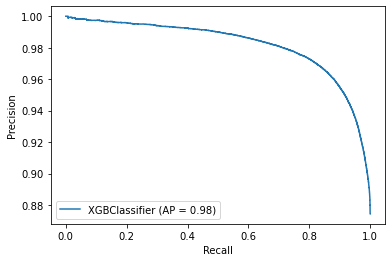

In [67]:
disp = plot_precision_recall_curve(xgb_class, X_test, y_test)

In [68]:
xgb.plot_importance(xgb_class)
plt.rcParams['figure.figsize'] = [5, 5]
plt.show()

NameError: name 'xgb' is not defined

In [ ]:
passes_outcome = pd.merge(passes_join,all_games[['id','type_name','player_name']],left_on='related_events',right_on = 'id')
print(passes_outcome.shape)
passes_outcome.head()
passes_outcome_combinations = passes_outcome['type_name'].value_counts()
passes_outcome_combinations.head(20)